Loaded: 1979 rows, 36 features
Class counts: {0: 1386, 1: 593}



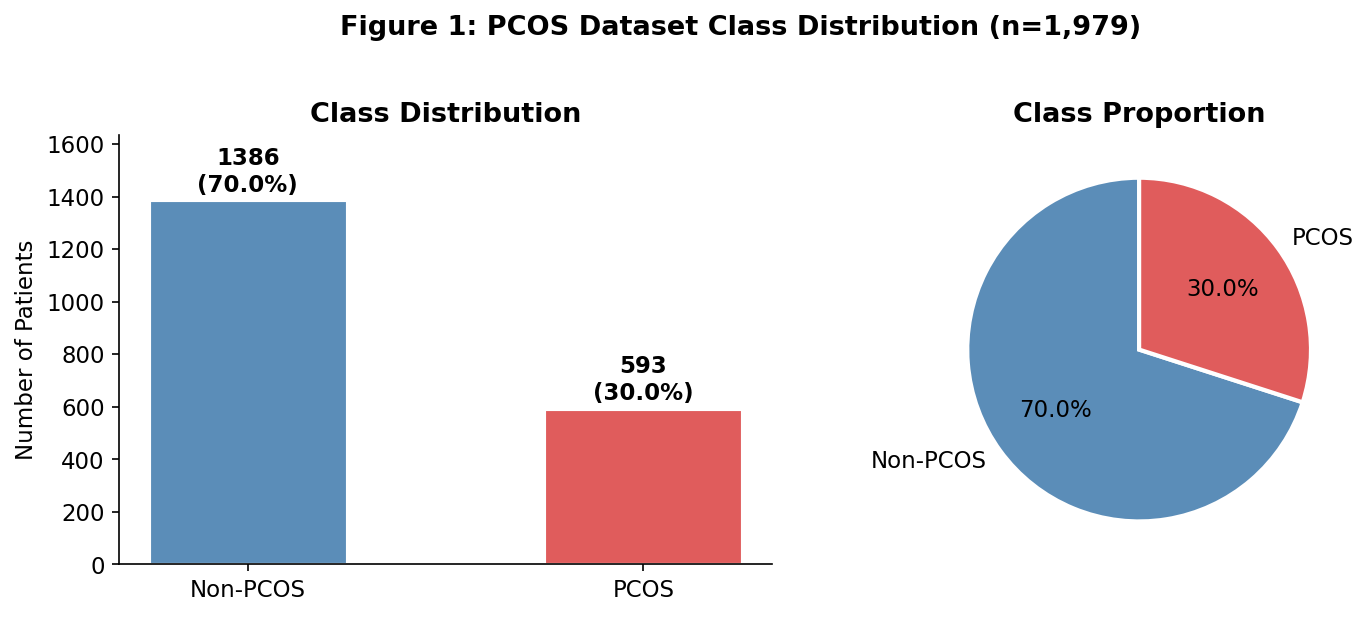

✓ Figure 1 saved


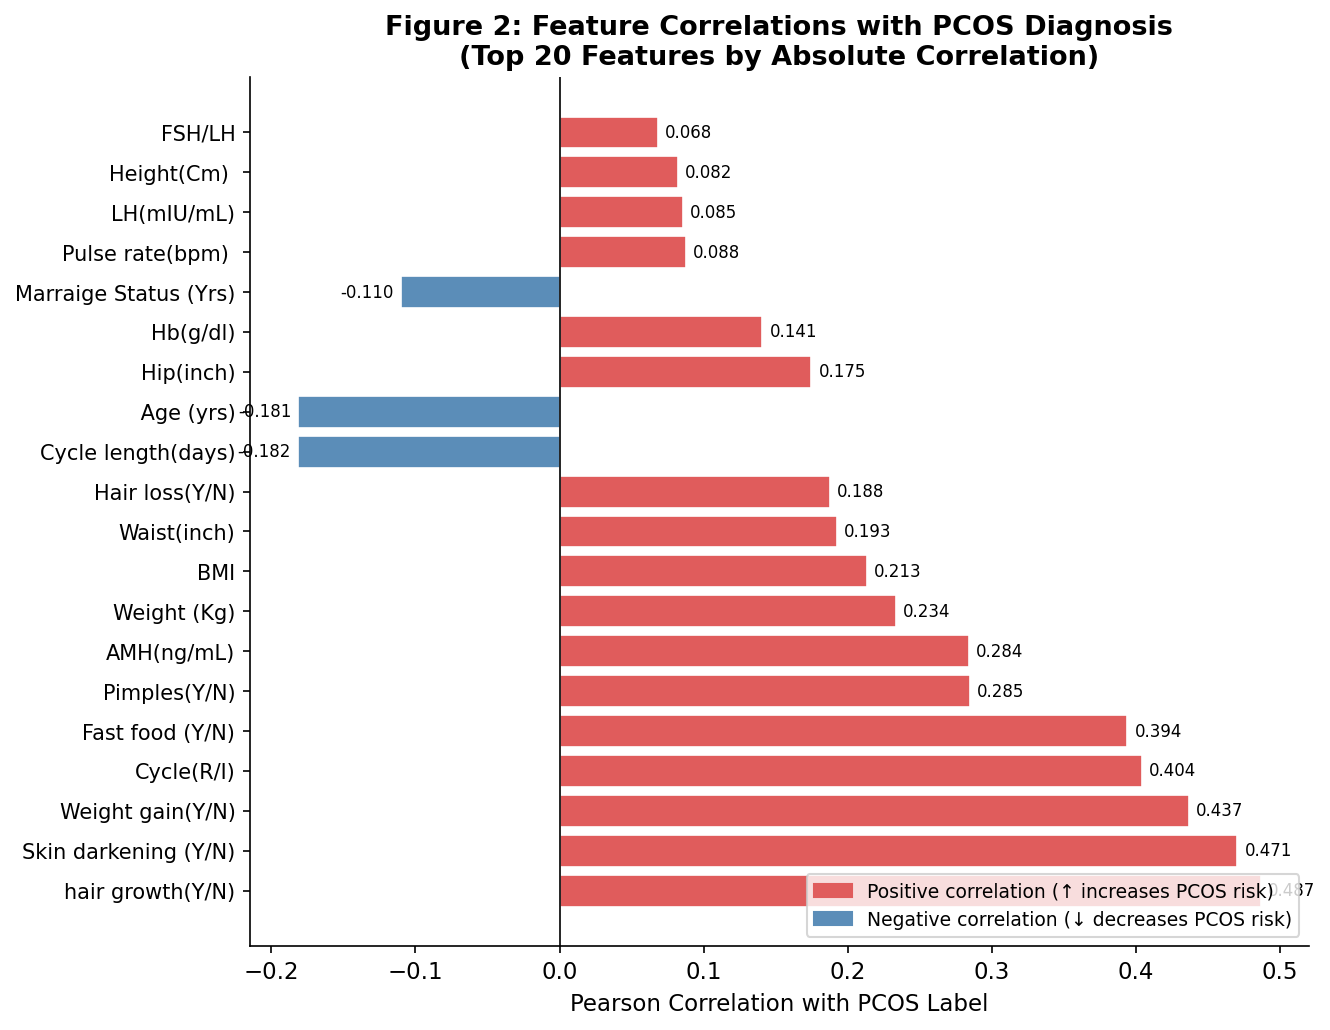

✓ Figure 2 saved


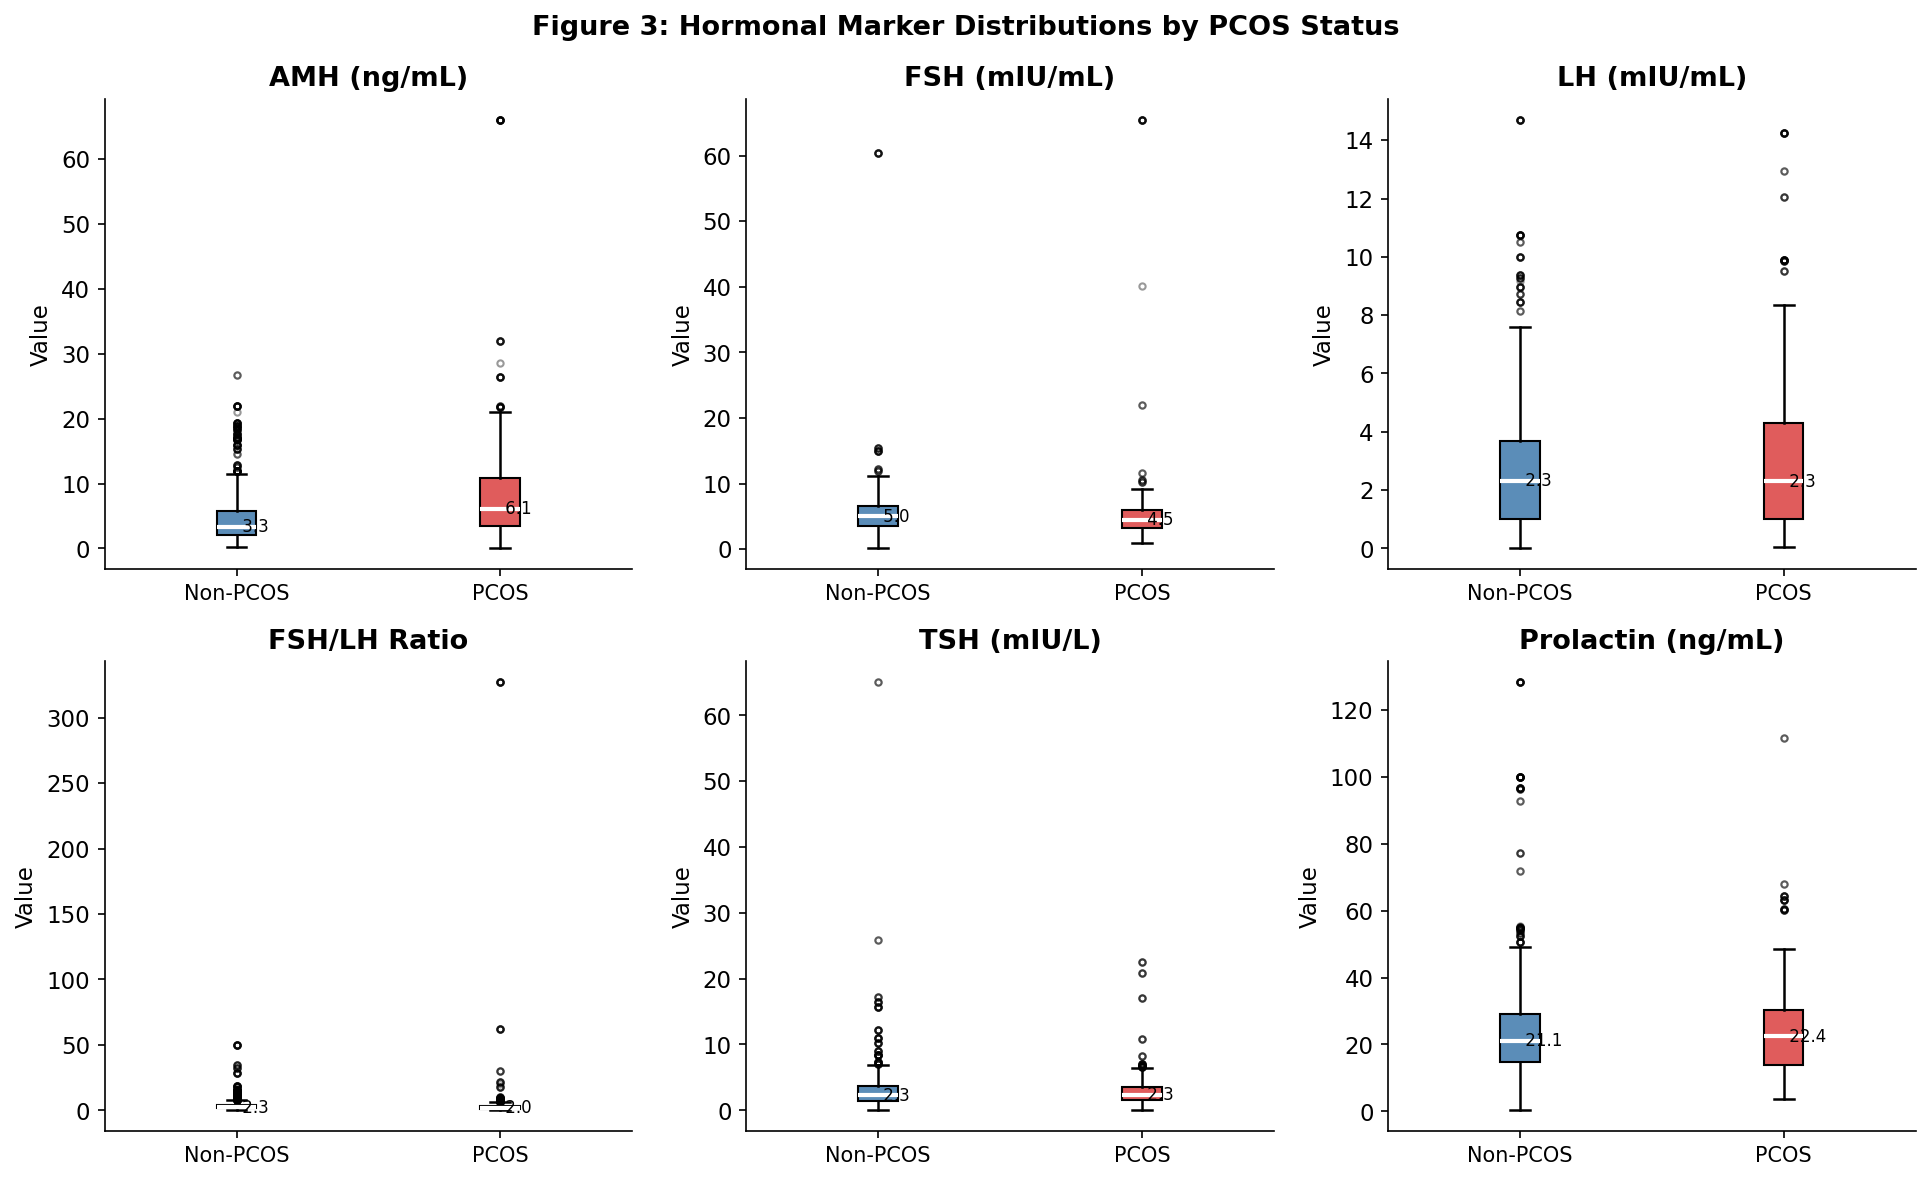

✓ Figure 3 saved


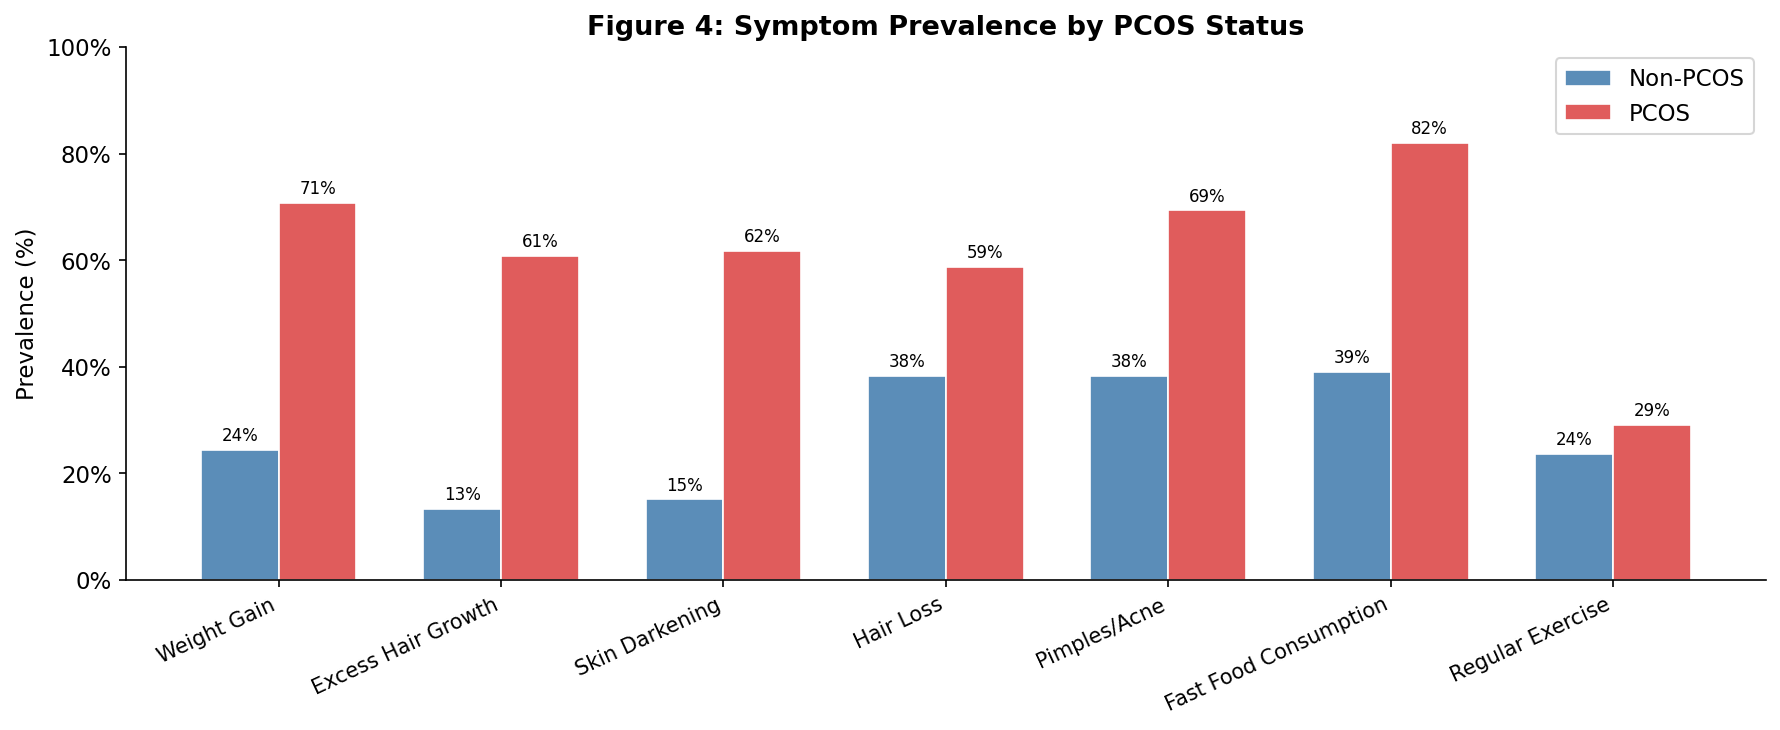

✓ Figure 4 saved


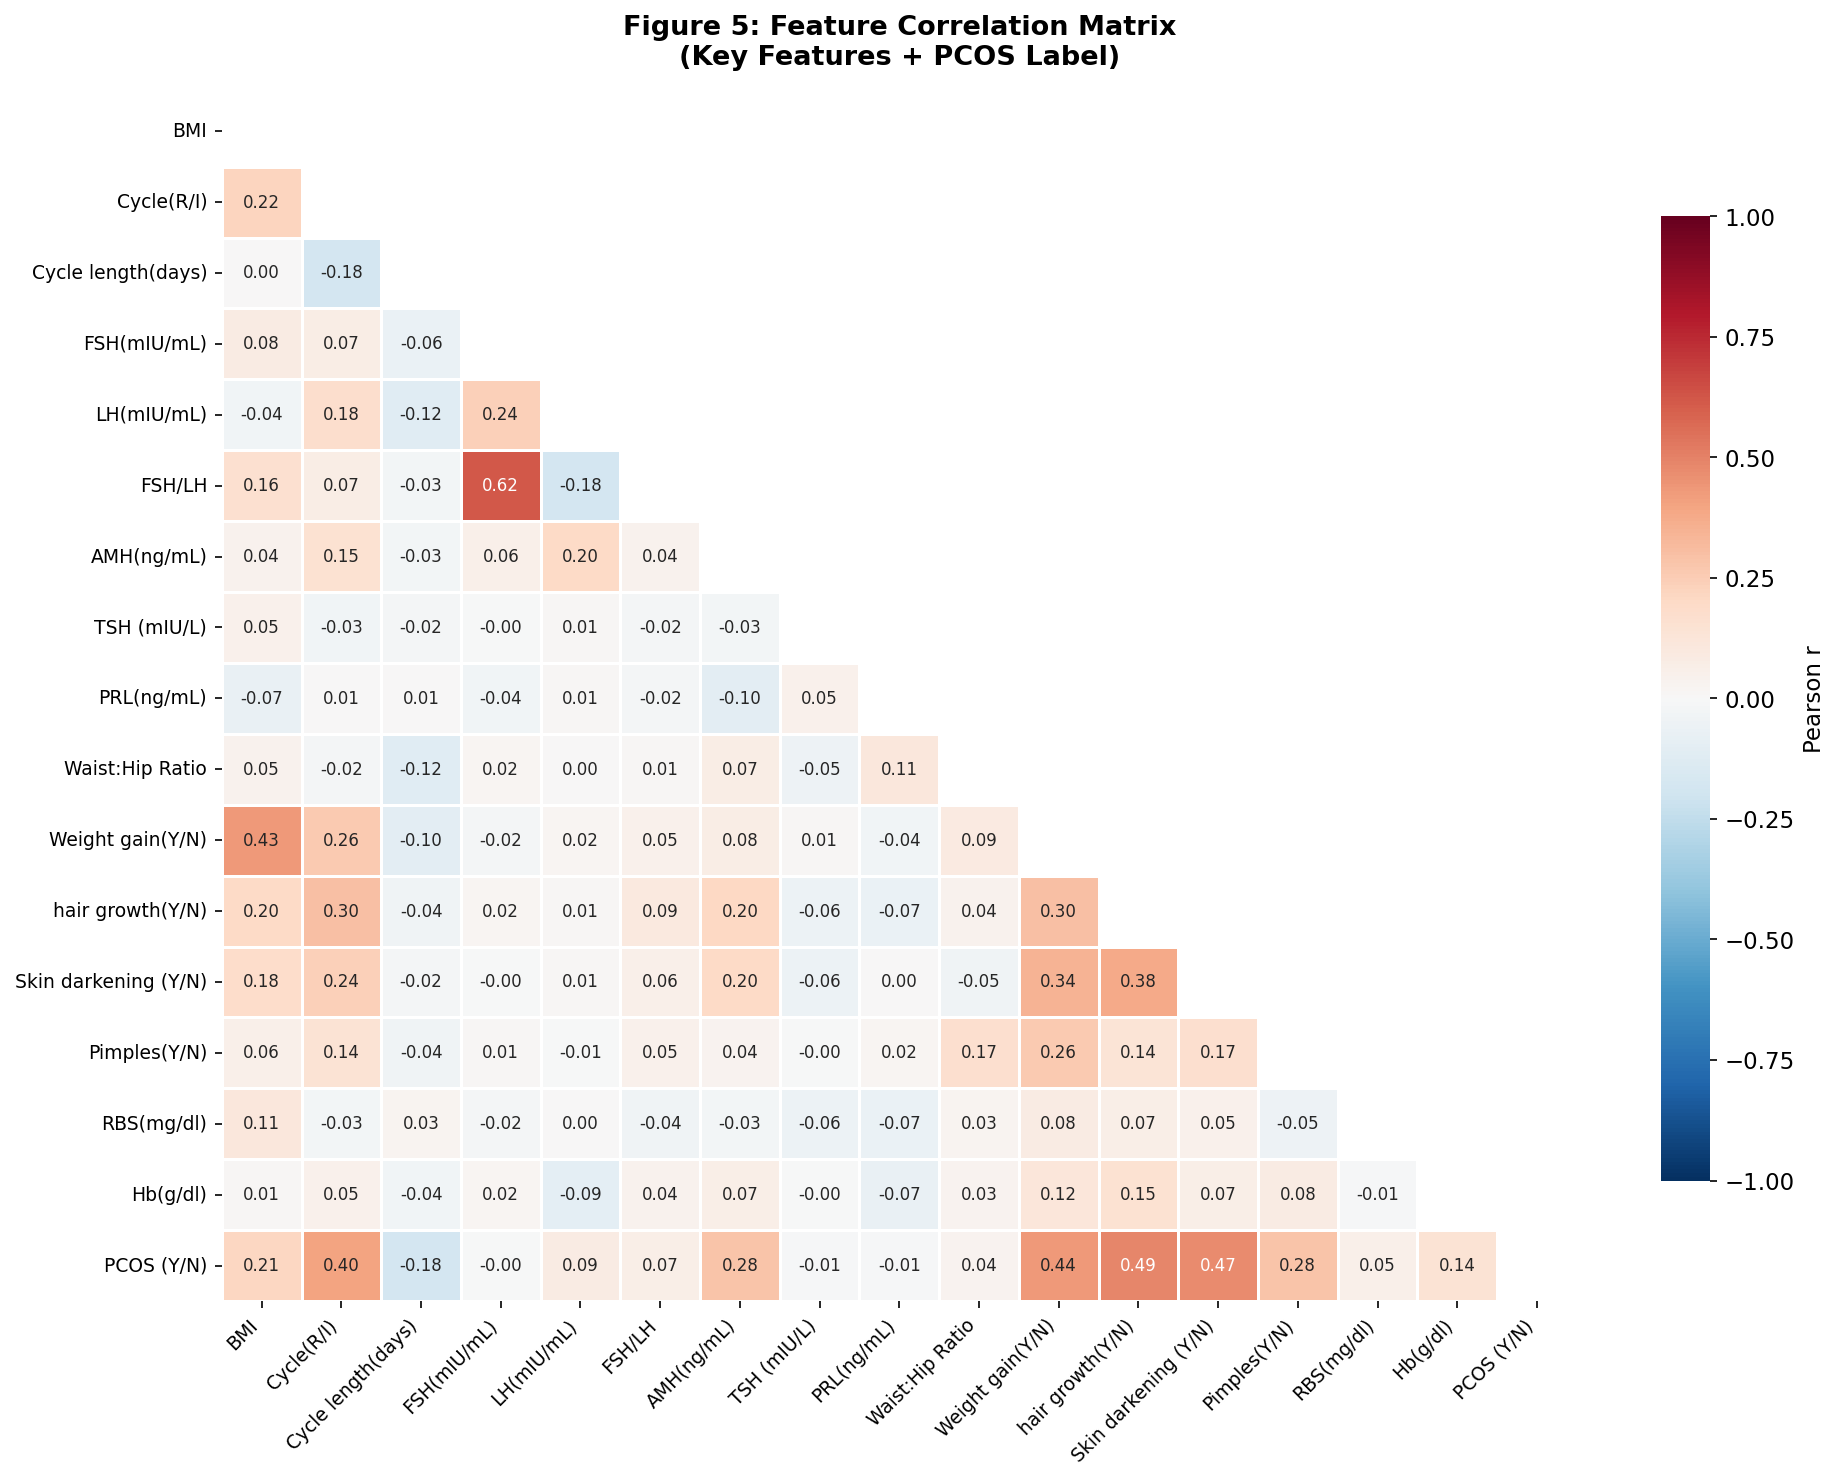

✓ Figure 5 saved

SUMMARY STATISTICS (for Methods/Dataset section)

BMI:
  PCOS:     median=25.05, IQR=[23.01, 28.36]
  Non-PCOS: median=23.66, IQR=[21.30, 26.11]

AMH(ng/mL):
  PCOS:     median=6.09, IQR=[3.49, 10.80]
  Non-PCOS: median=3.30, IQR=[2.00, 5.80]

FSH(mIU/mL):
  PCOS:     median=4.52, IQR=[3.27, 5.90]
  Non-PCOS: median=5.01, IQR=[3.51, 6.56]

LH(mIU/mL):
  PCOS:     median=2.30, IQR=[1.02, 4.30]
  Non-PCOS: median=2.31, IQR=[1.02, 3.68]

FSH/LH:
  PCOS:     median=2.03, IQR=[1.11, 3.15]
  Non-PCOS: median=2.30, IQR=[1.56, 4.11]

Cycle length(days):
  PCOS:     median=5.00, IQR=[4.00, 5.00]
  Non-PCOS: median=5.00, IQR=[5.00, 6.00]

Waist:Hip Ratio:
  PCOS:     median=0.90, IQR=[0.86, 0.93]
  Non-PCOS: median=0.89, IQR=[0.85, 0.93]

✓ EDA complete. 5 figures saved.
✓ Ready for Step 3: Pipeline Architecture


In [ ]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# PCOS Classification Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

PCOS_COLOR    = '#E05C5C'   # red for PCOS positive
NOPCOS_COLOR  = '#5B8DB8'   # blue for non-PCOS
NEUTRAL_COLOR = '#6A9E73'

# ── Load clean data ───────────────────────────────────────────
df = pd.read_csv('PCOS_clean.csv')
target = 'PCOS (Y/N)'
features = [c for c in df.columns if c != target]

print(f"Loaded: {df.shape[0]} rows, {len(features)} features")
print(f"Class counts: {df[target].value_counts().to_dict()}\n")

pcos    = df[df[target] == 1]
no_pcos = df[df[target] == 0]

# ════════════════════════════════════════════════════════════
# FIGURE 1 — Class Distribution
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df[target].value_counts().sort_index()
labels = ['Non-PCOS', 'PCOS']
colors = [NOPCOS_COLOR, PCOS_COLOR]

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(counts.values) * 1.18)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion')

plt.suptitle('Figure 1: PCOS Dataset Class Distribution (n=1,979)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png')
plt.show()
print("✓ Figure 1 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 2 — Feature Correlations with Target (Top 20)
# ════════════════════════════════════════════════════════════
correlations = df[features].apply(
    lambda col: col.corr(df[target])
).sort_values(key=abs, ascending=False).head(20)

colors_corr = [PCOS_COLOR if v > 0 else NOPCOS_COLOR
               for v in correlations.values]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(range(len(correlations)), correlations.values,
               color=colors_corr, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Pearson Correlation with PCOS Label')
ax.set_title('Figure 2: Feature Correlations with PCOS Diagnosis\n(Top 20 Features by Absolute Correlation)')

pos_patch = mpatches.Patch(color=PCOS_COLOR,   label='Positive correlation (↑ increases PCOS risk)')
neg_patch = mpatches.Patch(color=NOPCOS_COLOR, label='Negative correlation (↓ decreases PCOS risk)')
ax.legend(handles=[pos_patch, neg_patch], loc='lower right', fontsize=9)

for bar, val in zip(bars, correlations.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_feature_correlations.png')
plt.show()
print("✓ Figure 2 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 3 — Hormonal Markers by Class
# ════════════════════════════════════════════════════════════
hormonal_features = {
    'AMH(ng/mL)':      'AMH (ng/mL)',
    'FSH(mIU/mL)':     'FSH (mIU/mL)',
    'LH(mIU/mL)':      'LH (mIU/mL)',
    'FSH/LH':          'FSH/LH Ratio',
    'TSH (mIU/L)':     'TSH (mIU/L)',
    'PRL(ng/mL)':      'Prolactin (ng/mL)',
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for idx, (col, label) in enumerate(hormonal_features.items()):
    ax = axes[idx]
    data_to_plot = [no_pcos[col].dropna(), pcos[col].dropna()]

    bp = ax.boxplot(data_to_plot,
                    patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2},
                    whiskerprops={'linewidth': 1.2},
                    capprops={'linewidth': 1.2},
                    flierprops={'marker': 'o', 'markersize': 3,
                                'alpha': 0.4})
    bp['boxes'][0].set_facecolor(NOPCOS_COLOR)
    bp['boxes'][1].set_facecolor(PCOS_COLOR)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Non-PCOS', 'PCOS'], fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Value')

    # Annotate medians
    for i, d in enumerate(data_to_plot):
        med = d.median()
        ax.text(i + 1, med, f' {med:.1f}',
                va='center', fontsize=8, color='black')

plt.suptitle('Figure 3: Hormonal Marker Distributions by PCOS Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_hormonal_markers.png')
plt.show()
print("✓ Figure 3 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 4 — Symptom Prevalence by Class
# ════════════════════════════════════════════════════════════
symptom_cols = {
    'Weight gain(Y/N)':      'Weight Gain',
    'hair growth(Y/N)':      'Excess Hair Growth',
    'Skin darkening (Y/N)':  'Skin Darkening',
    'Hair loss(Y/N)':        'Hair Loss',
    'Pimples(Y/N)':          'Pimples/Acne',
    'Fast food (Y/N)':       'Fast Food Consumption',
    'Reg.Exercise(Y/N)':     'Regular Exercise',
}

pcos_rates   = [pcos[c].mean() * 100   for c in symptom_cols]
nopcos_rates = [no_pcos[c].mean() * 100 for c in symptom_cols]
labels_symp  = list(symptom_cols.values())

x = np.arange(len(labels_symp))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, nopcos_rates, width,
            label='Non-PCOS', color=NOPCOS_COLOR,
            edgecolor='white', linewidth=0.8)
b2 = ax.bar(x + width/2, pcos_rates, width,
            label='PCOS', color=PCOS_COLOR,
            edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels_symp, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Prevalence (%)')
ax.set_ylim(0, 100)
ax.set_title('Figure 4: Symptom Prevalence by PCOS Status')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_symptom_prevalence.png')
plt.show()
print("✓ Figure 4 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 5 — Feature Correlation Heatmap
# ════════════════════════════════════════════════════════════
# Select meaningful features only (drop near-zero variance)
heatmap_features = [
    'Age (yrs)', 'BMI', 'Cycle(R/I)', 'Cycle length(days)',
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
    'TSH (mIU/L)', 'PRL(ng/mL)', 'Waist:Hip Ratio',
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Pimples(Y/N)', 'RBS(mg/dl)', 'Hb(g/dl)', 'PCOS (Y/N)'
]
heatmap_features = [f for f in heatmap_features if f in df.columns]

corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Figure 5: Feature Correlation Matrix\n(Key Features + PCOS Label)',
             fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png')
plt.show()
print("✓ Figure 5 saved")

# ════════════════════════════════════════════════════════════
# SUMMARY STATISTICS TABLE (for paper)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SUMMARY STATISTICS (for Methods/Dataset section)")
print("="*60)

key_features = ['Age (yrs)', 'BMI', 'AMH(ng/mL)',
                'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
                'Cycle length(days)', 'Waist:Hip Ratio']

for feat in key_features:
    if feat not in df.columns:
        continue
    p_med = pcos[feat].median()
    n_med = no_pcos[feat].median()
    p_iqr = pcos[feat].quantile([0.25, 0.75]).values
    n_iqr = no_pcos[feat].quantile([0.25, 0.75]).values
    print(f"\n{feat}:")
    print(f"  PCOS:     median={p_med:.2f}, IQR=[{p_iqr[0]:.2f}, {p_iqr[1]:.2f}]")
    print(f"  Non-PCOS: median={n_med:.2f}, IQR=[{n_iqr[0]:.2f}, {n_iqr[1]:.2f}]")

print("\n" + "="*60)
print("✓ EDA complete. 5 figures saved.")
print("✓ Ready for Step 3: Pipeline Architecture")